In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

## Dataset Structuring and Validation

Talk about plans and goals here. Then load datasets.

In [4]:
listing = pd.read_csv('/Users/olee1232/Documents/IDXWork/Week1/listing.csv')
sold = pd.read_csv('/Users/olee1232/Documents/IDXWork/Week1/sold.csv')

/var/folders/q8/sdky6zrj6y52rcdpgrsws4vm0000gn/T/ipykernel_93603/817894108.py:1: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv('/Users/olee1232/Documents/IDXWork/Week1/listing.csv')
/var/folders/q8/sdky6zrj6y52rcdpgrsws4vm0000gn/T/ipykernel_93603/817894108.py:2: DtypeWarning: Columns (0,1,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv('/Users/olee1232/Documents/IDXWork/Week1/sold.csv')


### Dataset Understanding

Identify number of rows and columns

In [164]:
pd.concat([pd.Series(["Total number of rows in listing and sold: "]), pd.Series([listing.shape[0], sold.shape[0]])], ignore_index=True)

0    Total number of rows in listing and sold: 
1                                        540183
2                                        397603
dtype: object

In [165]:
pd.concat([pd.Series(["Total number of columns in listing and sold: "]), pd.Series([listing.shape[1], sold.shape[1]])], ignore_index=True)

0    Total number of columns in listing and sold: 
1                                               84
2                                               84
dtype: object

Review column data types

In [167]:
print(sold.dtypes.to_string())

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
ListAgentFirstName               object
ListAgentLastName                object
Latitude                        float64
Longitude                       float64
UnparsedAddress                  object
PropertyType                     object
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                   object
BuyerOfficeName                  object
CoListOfficeName                 object
ListAgentFullName                object


In [169]:
print(listing.dtypes.to_string())

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
ListAgentFirstName               object
ListAgentLastName                object
Latitude                        float64
Longitude                       float64
UnparsedAddress                  object
PropertyType                     object
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                   object
BuyerOfficeName                  object
CoListOfficeName                 object
ListAgentFullName                object
CoListAgentFirstName             object
CoListAgentLastName              object
BuyerAgentMlsId                  object
BuyerAgentFirstName              object
BuyerAgentLastName               object
FireplacesTotal                 float64
AssociationFeeFrequency          object


### Exploratory Data Analysis

#### What is the Residential vs. other property type share?

In [229]:
print(f"\nTotal Residential Counts: {len(sold[sold['PropertyType'] == 'Residential'])}")
print(f"\nTotal Non-residential Counts: {len(sold[sold['PropertyType'] != 'Residential'])}")


Total Residential Counts: 397603

Total Non-residential Counts: 0


This is intended because I filtered the sold and listing data to only the Residential property type.

#### What are the median and average close prices?

In [230]:
print(f"\nMedian: {sold['ClosePrice'].median()}")
print(f"\nMean: {round(sold['ClosePrice'].mean(), 2)}")


Median: 820000.0

Mean: 1185616.36


#### What does the Days on Market distribution look like?

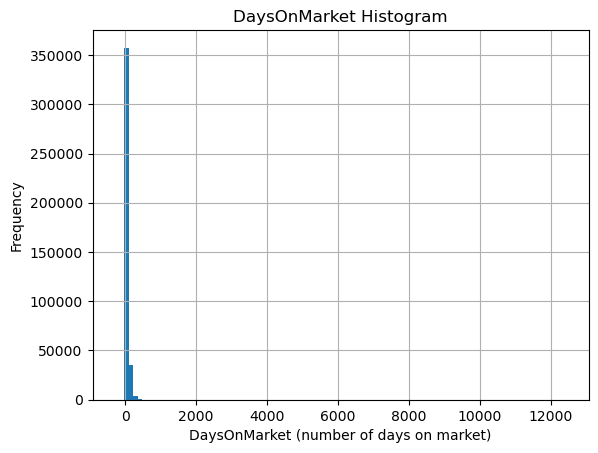

In [231]:
sold['DaysOnMarket'].hist(bins=100)
plt.title('DaysOnMarket Histogram')
plt.xlabel('DaysOnMarket (number of days on market)')
plt.ylabel('Frequency')
plt.show()

Extremely skewed to the left. Extreme high-value outliers (e.g., over 10,000 days).

#### What percentage of homes were sold above vs. below list price?

In [232]:
print(f"\nPercentage of homes sold above list price: {round(len(sold[sold['ClosePrice'] > sold['ListPrice']]) / len(sold), 3)}")
print(f"\nPercentage of homes sold below list price: {round(len(sold[sold['ClosePrice'] < sold['ListPrice']]) / len(sold), 2)}")


Percentage of homes sold above list price: 0.401

Percentage of homes sold below list price: 0.43


#### Are there any apparent date consistency issues (e.g., close date before listing date)?

In [233]:
print(f"\nNumber of close dates before listing dates: {len(sold[sold['CloseDate'] < sold['ListingContractDate']])}")
print(f"\nNumber of close dates on listing dates: {len(sold[sold['CloseDate'] == sold['ListingContractDate']])}")
print(f"\nNumber of close dates after listing dates: {len(sold[sold['CloseDate'] > sold['ListingContractDate']])}")


Number of close dates before listing dates: 58

Number of close dates on listing dates: 3648

Number of close dates after listing dates: 393896


#### Which counties have the highest median prices?

ClosePrice

In [234]:
sold['ClosePrice'].groupby(sold['CountyOrParish']).median().sort_values(ascending=False).head(10)

CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64

ListPrice

In [235]:
sold['ListPrice'].groupby(sold['CountyOrParish']).median().sort_values(ascending=False).head(10)

CountyOrParish
Del Norte        2485000.0
San Mateo        1599000.0
Santa Clara      1499000.0
Alpine           1295000.0
Santa Cruz       1199000.0
Marin            1195000.0
Orange           1170000.0
San Francisco    1088000.0
Alameda          1000000.0
Mono              975000.0
Name: ListPrice, dtype: float64

OriginalListPrice

In [236]:
sold['OriginalListPrice'].groupby(sold['CountyOrParish']).median().sort_values(ascending=False).head(10)

CountyOrParish
Del Norte        3250000.0
Alpine           1650000.0
San Mateo        1599888.0
Santa Clara      1499000.0
Marin            1270000.0
Santa Cruz       1220000.0
Orange           1188800.0
Mono             1150000.0
San Francisco    1095000.0
Alameda          1048000.0
Name: OriginalListPrice, dtype: float64

### Separate market analysis fields from metadata fields

**Core distinction:** Market analysis columns describe *what a property is and how it transacted*. Metadata columns describe *who was involved and how the record was administered*.

---

**Market Analysis** — anything you'd put into a pricing model, comp analysis, or market trend report:
- **Pricing fields** — list, original list, and close price are the core outcome variables
- **Time fields** — days on market and key dates measure market velocity
- **Property characteristics** — beds, baths, sqft, year built, stories; these are your predictors in any hedonic model
- **Lot and amenities** — garage, pool, fireplace, view; these drive valuation differentials
- **HOA** — directly affects effective cost of ownership, so it's analytically relevant
- **Location fields** — city, zip, lat/lon, school district; used for geographic segmentation and spatial modeling
- **Status/compensation** — MLS status and buyer compensation are transactional outcomes

**Metadata** — anything that identifies the record or the people behind it, but doesn't describe the property itself:
- **Listing identifiers** — `ListingKey`, `ListingId` are just database keys
- **Agent and office info** — who listed and sold the property is administrative, not analytical
- **Raw address** — `UnparsedAddress` is the source string; you've already extracted the usable location fields into lat/lon, city, zip for analysis
- **Tax fields** — heavily missing (100% null in your data) and more of a record-keeping field than a market signal
- **Individual school names** — too granular and sparse to be useful analytically; `HighSchoolDistrict` is the market-relevant signal, not the specific school
- **Builder and system fields** — provenance of the record, not the property
- **`latfilled`/`lonfilled`** — these are data quality flags, not features

The one genuine gray area was the school-related columns — district went to market analysis because it's a known price driver, but individual school names went to metadata because they're reference labels, not model inputs.

In [11]:
# Market Analysis columns — 49 total
sold_ma = sold[[
    # Pricing
    'OriginalListPrice', 'ListPrice', 'ClosePrice',
    # Time on market
    'DaysOnMarket', 'ListingContractDate', 'PurchaseContractDate', 'CloseDate', 'ContractStatusChangeDate',
    # Property characteristics
    'PropertyType', 'PropertySubType', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'YearBuilt', 'Stories', 'Levels', 'NewConstructionYN',
    'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
    # Lot
    'LotSizeSquareFeet', 'LotSizeAcres', 'LotSizeArea', 'LotSizeDimensions',
    # Amenities
    'GarageSpaces', 'CoveredSpaces', 'ParkingTotal', 'AttachedGarageYN',
    'FireplacesTotal', 'FireplaceYN', 'PoolPrivateYN',
    'ViewYN', 'WaterfrontYN', 'BasementYN', 'Flooring',
    # HOA
    'AssociationFee', 'AssociationFeeFrequency',
    # Location
    'City', 'PostalCode', 'CountyOrParish', 'StateOrProvince',
    'Latitude', 'Longitude', 'MLSAreaMajor', 'SubdivisionName', 'HighSchoolDistrict',
    # Status
    'MlsStatus', 'BuyerAgencyCompensation', 'BuyerAgencyCompensationType',
]]

# Metadata columns — 35 total
sold_md = sold[[
    # Listing identifiers
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    # Agent/office info
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName', 'ListAgentAOR',
    'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName',
    'ListOfficeName',
    'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentAOR',
    'BuyerOfficeName', 'BuyerOfficeAOR', 'CoBuyerAgentFirstName',
    # Address (raw)
    'UnparsedAddress', 'StreetNumberNumeric',
    # Tax/admin
    'TaxAnnualAmount', 'TaxYear',
    # Schools
    'ElementarySchool', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchool', 'MiddleOrJuniorSchoolDistrict',
    'HighSchool',
    # Builder/system
    'BuilderName', 'BuildingAreaTotal', 'BusinessType',
    'OriginatingSystemName', 'OriginatingSystemSubName',
    # Data quality flags
    'latfilled', 'lonfilled',
]]

In [12]:
pd.concat([pd.Series(["Total number of columns in sold_ma and sold_md: "]), pd.Series([sold_ma.shape[1], sold_md.shape[1]])], ignore_index=True)

0    Total number of columns in sold_ma and sold_md: 
1                                                  49
2                                                  35
dtype: object

In [13]:
# Market Analysis columns — 44 total
listing_ma = listing[[
    # Pricing
    'OriginalListPrice', 'ListPrice', 'ClosePrice',
    # Time on market
    'DaysOnMarket', 'ListingContractDate', 'PurchaseContractDate', 'CloseDate', 'ContractStatusChangeDate',
    # Property characteristics
    'PropertyType', 'PropertySubType', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'YearBuilt', 'Stories', 'Levels', 'NewConstructionYN',
    'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
    # Lot
    'LotSizeSquareFeet', 'LotSizeAcres', 'LotSizeArea', 'LotSizeDimensions',
    # Amenities
    'GarageSpaces', 'CoveredSpaces', 'ParkingTotal', 'AttachedGarageYN',
    'FireplacesTotal', 'FireplaceYN',
    # HOA
    'AssociationFee', 'AssociationFeeFrequency',
    # Location
    'City', 'PostalCode', 'CountyOrParish', 'StateOrProvince',
    'Latitude', 'Longitude', 'MLSAreaMajor', 'SubdivisionName', 'HighSchoolDistrict',
    # Status
    'MlsStatus', 'BuyerAgencyCompensation', 'BuyerAgencyCompensationType',
]]

# Metadata columns — 40 total
listing_md = listing[[
    # Listing identifiers
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    # Agent/office info
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
    'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName',
    'ListOfficeName',
    'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
    'BuyerOfficeName', 'BuyerOfficeAOR', 'CoBuyerAgentFirstName',
    # Address (raw)
    'UnparsedAddress', 'StreetNumberNumeric',
    # Tax/admin
    'TaxAnnualAmount', 'TaxYear',
    # Schools
    'ElementarySchool', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchool', 'MiddleOrJuniorSchoolDistrict',
    'HighSchool',
    # Builder/system
    'BuilderName', 'BuildingAreaTotal', 'BusinessType',
    # Merge duplicates (drop or reconcile upstream)
    'PropertyType.1', 'ListAgentFirstName.1', 'ListAgentLastName.1',
    'DaysOnMarket.1', 'LivingArea.1', 'ListPrice.1',
    'Latitude.1', 'Longitude.1', 'CloseDate.1',
    'BuyerOfficeName.1', 'UnparsedAddress.1',
]]

In [14]:
pd.concat([pd.Series(["Total number of columns in listing_ma and listing_md: "]), pd.Series([listing_ma.shape[1], listing_md.shape[1]])], ignore_index=True)

0    Total number of columns in listing_ma and list...
1                                                   44
2                                                   40
dtype: object

### Missing Value Analysis

Identify high-missing columns. Calculate missing counts and percentages per column. Flag columns with >90% missing values.

In [15]:
missing_sold_ma_data = sold_ma.isnull().mean().sort_values(ascending=False) * 100
print(missing_sold_ma_data.to_string())

CoveredSpaces                  100.000000
FireplacesTotal                100.000000
AboveGradeFinishedArea         100.000000
WaterfrontYN                    99.937626
BelowGradeFinishedArea          99.424049
BasementYN                      98.044029
LotSizeDimensions               95.140630
BuyerAgencyCompensation         88.399232
BuyerAgencyCompensationType     88.396466
SubdivisionName                 62.845351
AssociationFeeFrequency         58.361984
MainLevelBedrooms               41.961706
Flooring                        35.862405
HighSchoolDistrict              27.378315
AssociationFee                  22.886648
Stories                         15.468445
AttachedGarageYN                15.261203
MLSAreaMajor                    13.360563
Levels                           9.700380
PoolPrivateYN                    8.660649
ViewYN                           8.518296
LotSizeAcres                     7.888270
LotSizeSquareFeet                7.793452
LotSizeArea                      7

In [16]:
missing_sold_md_data = sold_md.isnull().mean().sort_values(ascending=False) * 100
print(missing_sold_md_data.to_string())

TaxYear                         100.000000
BusinessType                    100.000000
ElementarySchoolDistrict        100.000000
MiddleOrJuniorSchoolDistrict    100.000000
TaxAnnualAmount                 100.000000
BuilderName                      95.083790
BuildingAreaTotal                93.009862
CoBuyerAgentFirstName            90.938952
OriginatingSystemSubName         90.127841
OriginatingSystemName            90.127841
ElementarySchool                 86.676157
MiddleOrJuniorSchool             86.587123
lonfilled                        83.932717
latfilled                        83.932717
HighSchool                       82.583129
CoListAgentFirstName             77.114861
CoListAgentLastName              77.055757
CoListOfficeName                 76.337704
BuyerAgentAOR                    12.346738
ListAgentAOR                     11.616110
ListAgentEmail                    7.296726
BuyerOfficeAOR                    5.393822
BuyerOfficeName                   1.644354
ListAgentFi

In [17]:
missing_listing_ma_data = listing_ma.isnull().mean().sort_values(ascending=False) * 100
print(missing_listing_ma_data.to_string())

CoveredSpaces                  100.000000
AboveGradeFinishedArea         100.000000
FireplacesTotal                100.000000
BelowGradeFinishedArea          99.439264
LotSizeDimensions               94.780843
BuyerAgencyCompensation         85.376622
BuyerAgencyCompensationType     85.372920
ClosePrice                      73.049874
CloseDate                       69.302625
SubdivisionName                 63.172851
AssociationFeeFrequency         57.263187
PurchaseContractDate            50.555275
MainLevelBedrooms               45.554007
HighSchoolDistrict              30.065367
AssociationFee                  24.003347
AttachedGarageYN                17.477966
Stories                         17.447606
Longitude                       14.836639
Latitude                        14.836639
MLSAreaMajor                    13.514309
Levels                          10.744507
LotSizeAcres                     8.241281
LotSizeSquareFeet                8.118360
LotSizeArea                      8

In [18]:
missing_listing_md_data = listing_md.isnull().mean().sort_values(ascending=False) * 100
print(missing_listing_md_data.to_string())

TaxYear                         100.000000
MiddleOrJuniorSchoolDistrict    100.000000
ElementarySchoolDistrict        100.000000
BusinessType                    100.000000
TaxAnnualAmount                 100.000000
CoBuyerAgentFirstName            97.329053
BuilderName                      95.327509
BuildingAreaTotal                91.114678
ElementarySchool                 88.089592
MiddleOrJuniorSchool             88.062934
HighSchool                       84.363447
CoListAgentFirstName             77.685340
CoListAgentLastName              77.611106
CoListOfficeName                 77.595370
BuyerOfficeAOR                   72.839760
BuyerOfficeName                  70.945032
BuyerOfficeName.1                70.945032
BuyerAgentFirstName              70.661979
BuyerAgentMlsId                  70.547574
BuyerAgentLastName               70.527210
CloseDate.1                      69.302625
Longitude.1                      14.836639
Latitude.1                       14.836639
ListAgentEm

**sold_ma — drop vs. retain:**

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `CoveredSpaces` | 100% | **Drop** | Entirely empty |
| `FireplacesTotal` | 100% | **Drop** | Entirely empty; use `FireplaceYN` instead |
| `AboveGradeFinishedArea` | 100% | **Drop** | Entirely empty; `LivingArea` covers this |
| `WaterfrontYN` | 99.9% | **Drop** | Effectively empty |
| `BelowGradeFinishedArea` | 99.4% | **Drop** | Effectively empty |
| `BasementYN` | 98% | **Drop** | Effectively empty |
| `LotSizeDimensions` | 95% | **Drop** | Effectively empty; lot size numerics already covered |
| `BuyerAgencyCompensation` | 88% | **Retain** | Analytically meaningful transactional field; impute or filter as needed |
| `BuyerAgencyCompensationType` | 88% | **Retain** | Same reasoning |

Everything below 90% missing is a straightforward retain.

---

**sold_md — drop vs. retain:**

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `TaxYear` | 100% | **Drop** | Entirely empty |
| `BusinessType` | 100% | **Drop** | Entirely empty |
| `ElementarySchoolDistrict` | 100% | **Drop** | Entirely empty |
| `MiddleOrJuniorSchoolDistrict` | 100% | **Drop** | Entirely empty |
| `TaxAnnualAmount` | 100% | **Drop** | Entirely empty |
| `BuilderName` | 95% | **Drop** | Effectively empty |
| `BuildingAreaTotal` | 93% | **Drop** | Effectively empty |
| `CoBuyerAgentFirstName` | 91% | **Drop** | Effectively empty |
| `OriginatingSystemName` | 90% | **Drop** | Effectively empty |
| `OriginatingSystemSubName` | 90% | **Drop** | Effectively empty |

Everything below 90% is a retain — even `ElementarySchool`, `HighSchool`, and the co-agent fields at 80%+ missing are worth keeping in metadata since they're reference fields, not model inputs, so sparsity doesn't hurt you.

---

**General decision rule:**

- **>90% missing → drop**, unless the field is a non-negotiable key (e.g. `ListingKey`) or has a domain-specific reason to survive
- **Analytical fields at 85–90%** (`BuyerAgencyCompensation`) → **retain with a note**; you'll use them conditionally or filter to non-null subsets
- **Metadata fields at 80–90%** → **retain**; sparsity is irrelevant for reference/admin columns you're not modeling on

In [19]:
sold_ma_new = sold_ma.drop(columns=['CoveredSpaces', 'FireplacesTotal', 'AboveGradeFinishedArea', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions'])
sold_md_new = sold_md.drop(columns=['TaxYear', 'BusinessType', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict', 'TaxAnnualAmount', 'BuilderName', 'BuildingAreaTotal', 'CoBuyerAgentFirstName', 'OriginatingSystemName', 'OriginatingSystemSubName'])

**listing_ma — drop vs. retain:**

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `CoveredSpaces` | 100% | **Drop** | Entirely empty |
| `AboveGradeFinishedArea` | 100% | **Drop** | Entirely empty; `LivingArea` covers this |
| `FireplacesTotal` | 100% | **Drop** | Entirely empty; use `FireplaceYN` instead |
| `BelowGradeFinishedArea` | 99.4% | **Drop** | Effectively empty |
| `LotSizeDimensions` | 94.8% | **Drop** | Effectively empty; lot size numerics already covered |
| `BuyerAgencyCompensation` | 85% | **Retain** | Analytically meaningful; will be sparse for active listings since compensation is only recorded at close |
| `BuyerAgencyCompensationType` | 85% | **Retain** | Same reasoning |
| `ClosePrice` | 73% | **Retain** | Core outcome variable — high missingness just reflects active/pending listings that haven't closed yet |
| `CloseDate` | 69% | **Retain** | Same reasoning as `ClosePrice` |
| `PurchaseContractDate` | 50.6% | **Retain** | Same reasoning; only populated once under contract |

Everything below 50% missing is a straightforward retain.

---

**listing_md — drop vs. retain:**

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `TaxYear` | 100% | **Drop** | Entirely empty |
| `MiddleOrJuniorSchoolDistrict` | 100% | **Drop** | Entirely empty |
| `ElementarySchoolDistrict` | 100% | **Drop** | Entirely empty |
| `BusinessType` | 100% | **Drop** | Entirely empty |
| `TaxAnnualAmount` | 100% | **Drop** | Entirely empty |
| `CoBuyerAgentFirstName` | 97.3% | **Drop** | Effectively empty |
| `BuilderName` | 95.3% | **Drop** | Effectively empty |
| `BuildingAreaTotal` | 91.1% | **Drop** | Effectively empty |

Everything below 90% is a retain, with two notes:

- **Buyer-side fields** (`BuyerOfficeName`, `BuyerAgentFirstName`, etc.) at 70%+ missing — retain, same logic as `ClosePrice`; these only populate at close so sparsity is structural, not a data quality problem
- **`.1` duplicate columns** — retain as a group for consistency, but flag them for reconciliation; their missingness mirrors their originals exactly which confirms they're just merge artifacts

---

**One difference from sold:** `ClosePrice`, `CloseDate`, and `PurchaseContractDate` warranted explicit discussion here because the missingness pattern is *structural* (listings dataset contains active/pending records), not random. That's an important distinction — don't impute or drop rows on those fields without first segmenting by `MlsStatus`.

In [20]:
listing_ma_new = listing_ma.drop(columns=['CoveredSpaces', 'AboveGradeFinishedArea', 'FireplacesTotal', 'BelowGradeFinishedArea', 'LotSizeDimensions'])
listing_md_new = listing_md.drop(columns=['TaxYear', 'MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'BusinessType', 'TaxAnnualAmount', 'CoBuyerAgentFirstName', 'BuilderName', 'BuildingAreaTotal'])

### Numeric Distribution Review

Analyze the distribution of key numeric fields: `ClosePrice`, `ListPrice`, `OriginalListPrice`, `LivingArea`, `LotSizeAcres`, `BedroomsTotal`, `BathroomsTotalInteger`, `DaysOnMarket`, and `YearBuilt`. For each field, generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

In [36]:
print(sold_ma_new.dtypes.to_string())

OriginalListPrice              float64
ListPrice                      float64
ClosePrice                     float64
DaysOnMarket                     int64
ListingContractDate             object
PurchaseContractDate            object
CloseDate                       object
ContractStatusChangeDate        object
PropertyType                    object
PropertySubType                 object
LivingArea                     float64
BedroomsTotal                  float64
BathroomsTotalInteger          float64
YearBuilt                      float64
Stories                        float64
Levels                          object
NewConstructionYN               object
MainLevelBedrooms              float64
LotSizeSquareFeet              float64
LotSizeAcres                   float64
LotSizeArea                    float64
GarageSpaces                   float64
ParkingTotal                   float64
AttachedGarageYN                object
FireplaceYN                     object
PoolPrivateYN            

#### ClosePrice

In [153]:
close_price = sold_ma['ClosePrice'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: ${np.percentile(close_price, p):,.0f}")

print(f"\nMean:  ${close_price.mean():,.0f}")
print(f"Std:   ${close_price.std():,.0f}")
print(f"Count: {close_price.count():,} total entries")

1th percentile: $203,000
5th percentile: $340,000
10th percentile: $415,000
25th percentile: $575,000
50th percentile: $820,000
75th percentile: $1,300,000
90th percentile: $2,058,600
95th percentile: $2,850,000
99th percentile: $5,550,000
99.9th percentile: $15,306,112
100th percentile: $989,500,000

Mean:  $1,185,616
Std:   $5,922,380
Count: 397,601 total entries


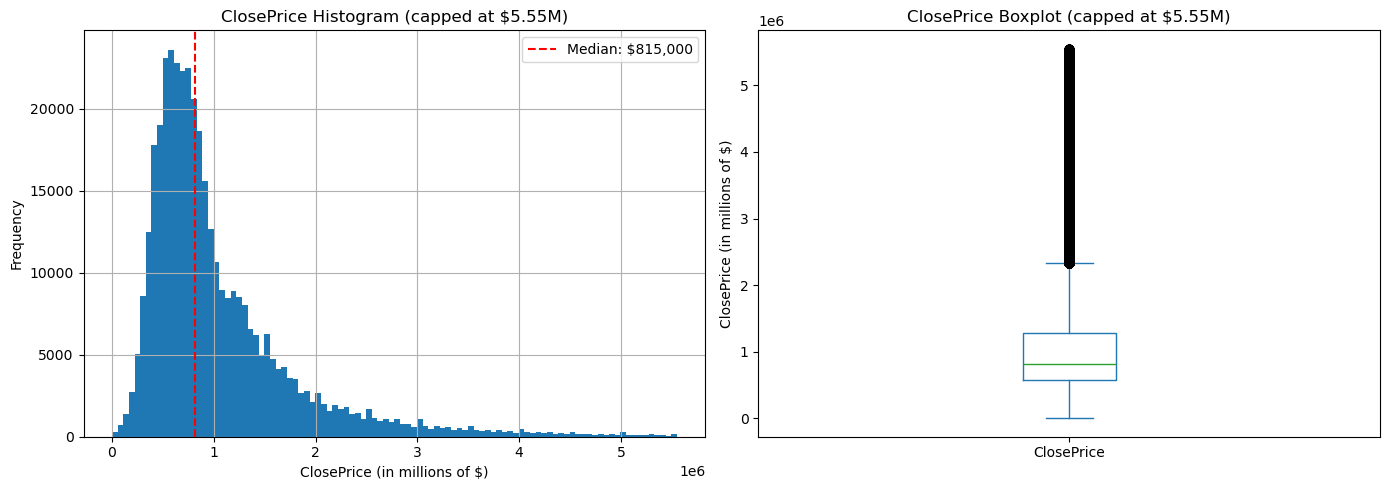

In [107]:
# Adjust upper cap based on what the percentile summary tells you
close_price_cap = close_price.quantile(0.99)
close_price_trimmed = close_price[close_price <= close_price_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

close_price_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(close_price_trimmed.median(), color='red', linestyle='--', label=f'Median: ${close_price_trimmed.median():,.0f}')
axes[0].set_title('ClosePrice Histogram (capped at $5.55M)')
axes[0].set_xlabel('ClosePrice (in millions of $)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

close_price_trimmed.plot.box(ax=axes[1])
axes[1].set_title('ClosePrice Boxplot (capped at $5.55M)')
axes[1].set_ylabel('ClosePrice (in millions of $)')

plt.tight_layout()
plt.show()

#### ListPrice

In [152]:
list_price = sold_ma['ListPrice'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: ${np.percentile(list_price, p):,.0f}")

print(f"\nMean:  ${list_price.mean():,.0f}")
print(f"Std:   ${list_price.std():,.0f}")
print(f"Count: {list_price.count():,} total entries")

1th percentile: $214,990
5th percentile: $346,500
10th percentile: $419,000
25th percentile: $575,000
50th percentile: $815,000
75th percentile: $1,295,000
90th percentile: $1,999,000
95th percentile: $2,850,000
99th percentile: $5,695,000
99.9th percentile: $15,950,000
100th percentile: $137,500,000

Mean:  $1,138,630
Std:   $1,353,707
Count: 397,603 total entries


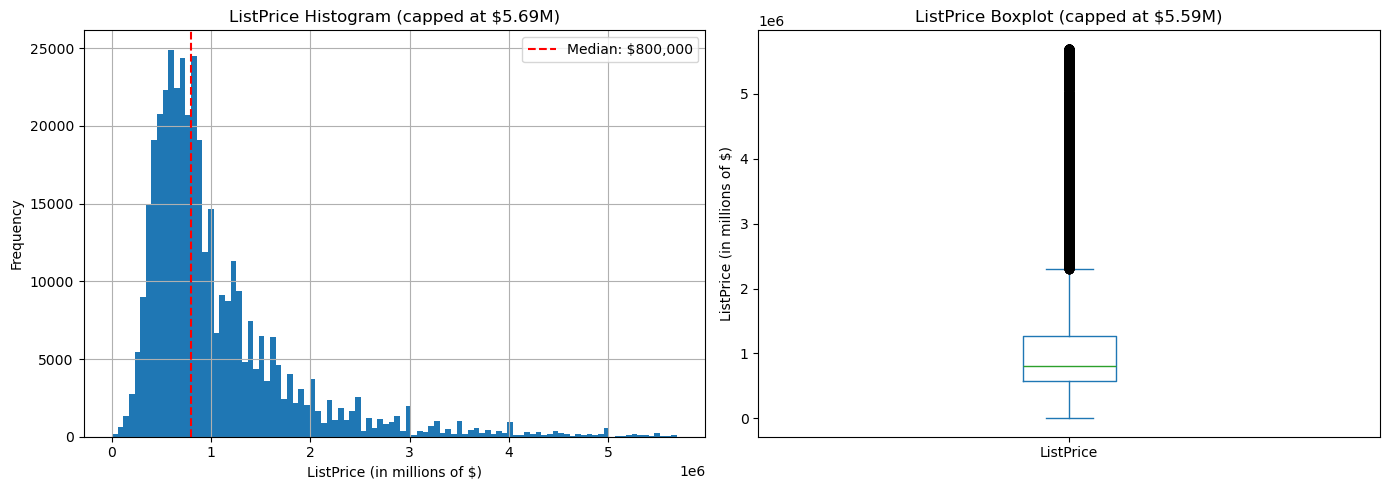

In [108]:
# Adjust upper cap based on what the percentile summary tells you
list_price_cap = list_price.quantile(0.99)
list_price_trimmed = list_price[list_price <= list_price_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

list_price_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(list_price_trimmed.median(), color='red', linestyle='--', label=f'Median: ${list_price_trimmed.median():,.0f}')
axes[0].set_title('ListPrice Histogram (capped at $5.69M)')
axes[0].set_xlabel('ListPrice (in millions of $)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

list_price_trimmed.plot.box(ax=axes[1])
axes[1].set_title('ListPrice Boxplot (capped at $5.59M)')
axes[1].set_ylabel('ListPrice (in millions of $)')

plt.tight_layout()
plt.show()

#### OriginalListPrice

In [151]:
ol_price = sold_ma['OriginalListPrice'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: ${np.percentile(ol_price, p):,.0f}")

print(f"\nMean:  ${ol_price.mean():,.0f}")
print(f"Std:   ${ol_price.std():,.0f}")
print(f"Count: {ol_price.count():,} total entries")

1th percentile: $210,405
5th percentile: $349,900
10th percentile: $425,000
25th percentile: $585,000
50th percentile: $825,000
75th percentile: $1,299,000
90th percentile: $2,050,000
95th percentile: $2,899,000
99th percentile: $5,995,000
99.9th percentile: $17,995,357
100th percentile: $1,390,000,000

Mean:  $1,224,737
Std:   $6,779,804
Count: 396,882 total entries


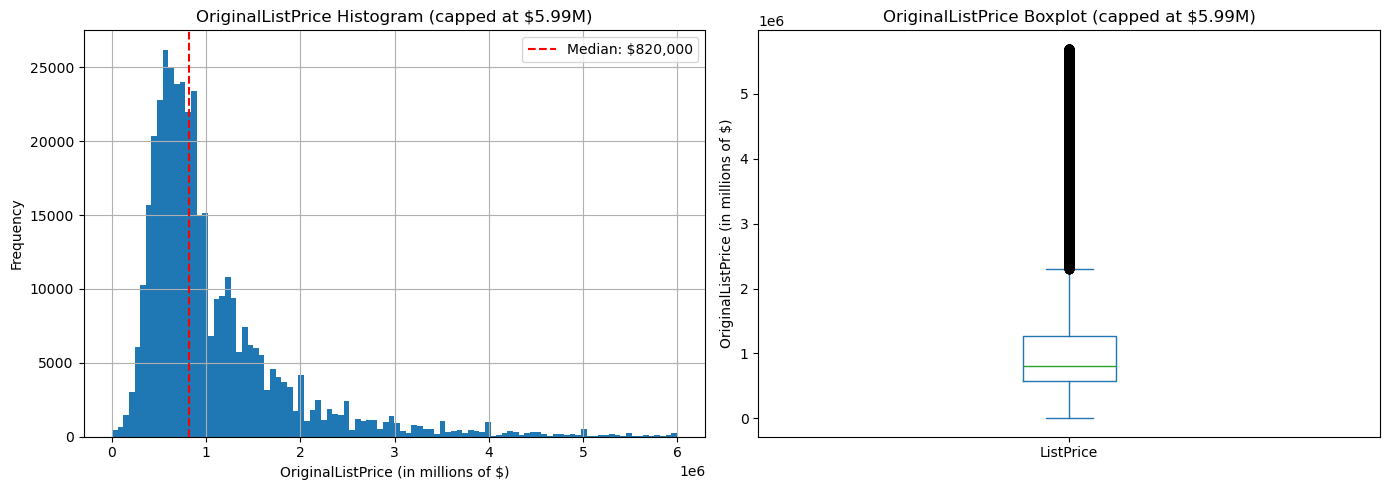

In [109]:
# Adjust upper cap based on what the percentile summary tells you
ol_price_cap = ol_price.quantile(0.99)
ol_price_trimmed = ol_price[ol_price <= ol_price_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ol_price_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(ol_price_trimmed.median(), color='red', linestyle='--', label=f'Median: ${ol_price_trimmed.median():,.0f}')
axes[0].set_title('OriginalListPrice Histogram (capped at $5.99M)')
axes[0].set_xlabel('OriginalListPrice (in millions of $)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

list_price_trimmed.plot.box(ax=axes[1])
axes[1].set_title('OriginalListPrice Boxplot (capped at $5.99M)')
axes[1].set_ylabel('OriginalListPrice (in millions of $)')

plt.tight_layout()
plt.show()

#### LivingArea

In [150]:
living_area = sold_ma['LivingArea'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(living_area, p):,.0f} sqft")

print(f"\nMean:  {living_area.mean():,.0f} sqft")
print(f"Std:   {living_area.std():,.0f} sqft")
print(f"Count: {living_area.count():,} total entries")

1th percentile: 604 sqft
5th percentile: 839 sqft
10th percentile: 982 sqft
25th percentile: 1,247 sqft
50th percentile: 1,641 sqft
75th percentile: 2,217 sqft
90th percentile: 2,975 sqft
95th percentile: 3,558 sqft
99th percentile: 5,280 sqft
99.9th percentile: 9,411 sqft
100th percentile: 17,021,321 sqft

Mean:  1,904 sqft
Std:   27,018 sqft
Count: 397,374 total entries


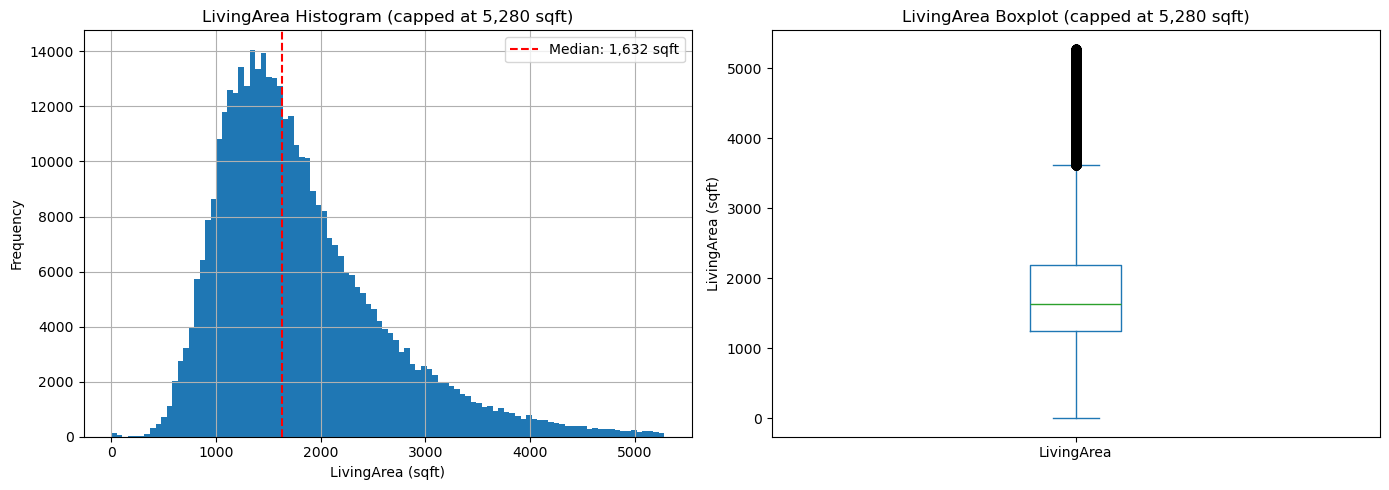

In [110]:
# Adjust upper cap based on what the percentile summary tells you
living_area_cap = living_area.quantile(0.99)
living_area_trimmed = living_area[living_area <= living_area_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

living_area_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(living_area_trimmed.median(), color='red', linestyle='--', label=f'Median: {living_area_trimmed.median():,.0f} sqft')
axes[0].set_title('LivingArea Histogram (capped at 5,280 sqft)')
axes[0].set_xlabel('LivingArea (sqft)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

living_area_trimmed.plot.box(ax=axes[1])
axes[1].set_title('LivingArea Boxplot (capped at 5,280 sqft)')
axes[1].set_ylabel('LivingArea (sqft)')

plt.tight_layout()
plt.show()

#### LotSizeAcres

In [149]:
lot_size = sold_ma['LotSizeAcres'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(lot_size, p):,.3f} acres")

print(f"\nMean:  {lot_size.mean():,.3f} acres")
print(f"Std:   {lot_size.std():,.3f} acres")
print(f"Count: {lot_size.count():,} total entries")

1th percentile: 0.000 acres
5th percentile: 0.030 acres
10th percentile: 0.062 acres
25th percentile: 0.120 acres
50th percentile: 0.166 acres
75th percentile: 0.272 acres
90th percentile: 1.040 acres
95th percentile: 2.810 acres
99th percentile: 10.799 acres
99.9th percentile: 432.772 acres
100th percentile: 7,810,698.356 acres

Mean:  68.559 acres
Std:   16,327.237 acres
Count: 366,239 total entries


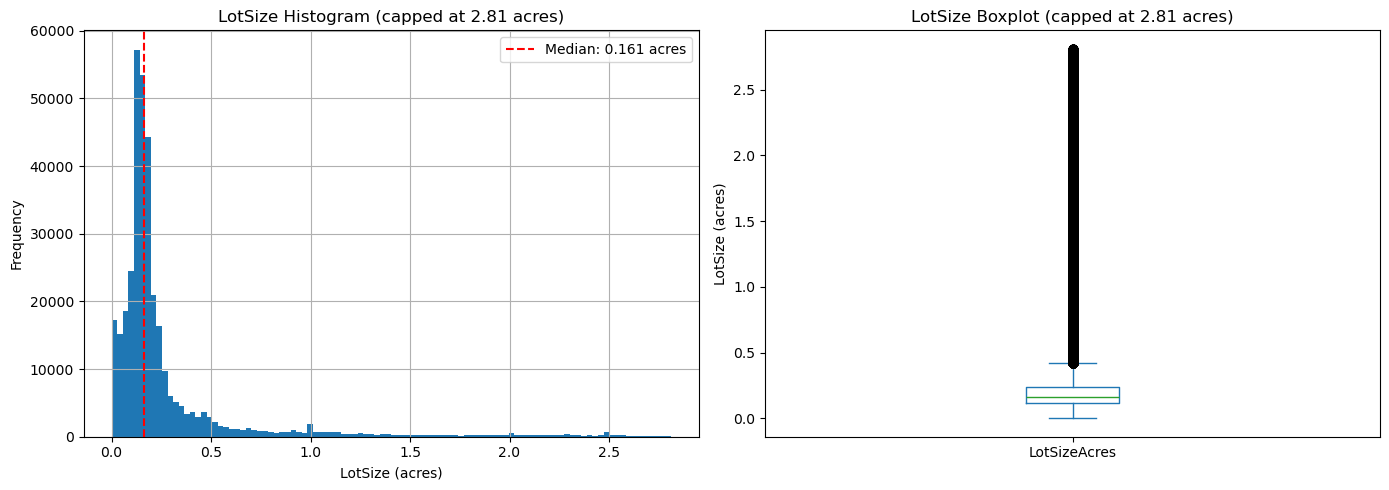

In [118]:
# Adjust upper cap based on what the percentile summary tells you
lot_size_cap = lot_size.quantile(0.95)
lot_size_trimmed = lot_size[lot_size <= lot_size_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lot_size_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(lot_size_trimmed.median(), color='red', linestyle='--', label=f'Median: {lot_size_trimmed.median():,.3f} acres')
axes[0].set_title('LotSize Histogram (capped at 2.81 acres)')
axes[0].set_xlabel('LotSize (acres)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

lot_size_trimmed.plot.box(ax=axes[1])
axes[1].set_title('LotSize Boxplot (capped at 2.81 acres)')
axes[1].set_ylabel('LotSize (acres)')

plt.tight_layout()
plt.show()

#### BedroomsTotal

In [148]:
bd_total = sold_ma['BedroomsTotal'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(bd_total, p):,.0f} bedrooms")

print(f"\nMean:  {bd_total.mean():,.0f} bedrooms")
print(f"Std:   {bd_total.std():,.0f} bedrooms")
print(f"Count: {bd_total.count():,} total entries")

1th percentile: 1 bedrooms
5th percentile: 2 bedrooms
10th percentile: 2 bedrooms
25th percentile: 3 bedrooms
50th percentile: 3 bedrooms
75th percentile: 4 bedrooms
90th percentile: 4 bedrooms
95th percentile: 5 bedrooms
99th percentile: 6 bedrooms
99.9th percentile: 8 bedrooms
100th percentile: 45 bedrooms

Mean:  3 bedrooms
Std:   1 bedrooms
Count: 397,592 total entries


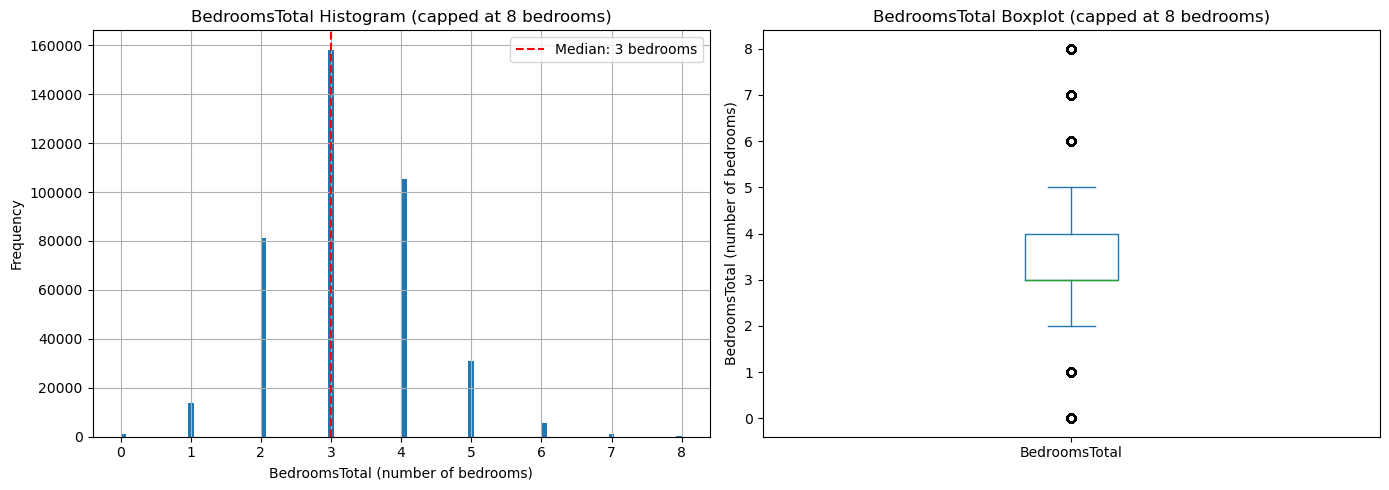

In [111]:
# Adjust upper cap based on what the percentile summary tells you
bd_total_cap = bd_total.quantile(0.999)
bd_total_trimmed = bd_total[bd_total <= bd_total_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bd_total_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(bd_total_trimmed.median(), color='red', linestyle='--', label=f'Median: {bd_total_trimmed.median():,.0f} bedrooms')
axes[0].set_title('BedroomsTotal Histogram (capped at 8 bedrooms)')
axes[0].set_xlabel('BedroomsTotal (number of bedrooms)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

bd_total_trimmed.plot.box(ax=axes[1])
axes[1].set_title('BedroomsTotal Boxplot (capped at 8 bedrooms)')
axes[1].set_ylabel('BedroomsTotal (number of bedrooms)')

plt.tight_layout()
plt.show()

#### BathroomsTotalInteger

In [147]:
bth_total = sold_ma['BathroomsTotalInteger'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(bd_total, p):,.0f} bathrooms")

print(f"\nMean:  {bth_total.mean():,.0f} bathrooms")
print(f"Std:   {bth_total.std():,.0f} bathrooms")
print(f"Count: {bth_total.count():,} total entries")

1th percentile: 1 bathrooms
5th percentile: 2 bathrooms
10th percentile: 2 bathrooms
25th percentile: 3 bathrooms
50th percentile: 3 bathrooms
75th percentile: 4 bathrooms
90th percentile: 4 bathrooms
95th percentile: 5 bathrooms
99th percentile: 6 bathrooms
99.9th percentile: 8 bathrooms
100th percentile: 45 bathrooms

Mean:  3 bathrooms
Std:   1 bathrooms
Count: 397,534 total entries


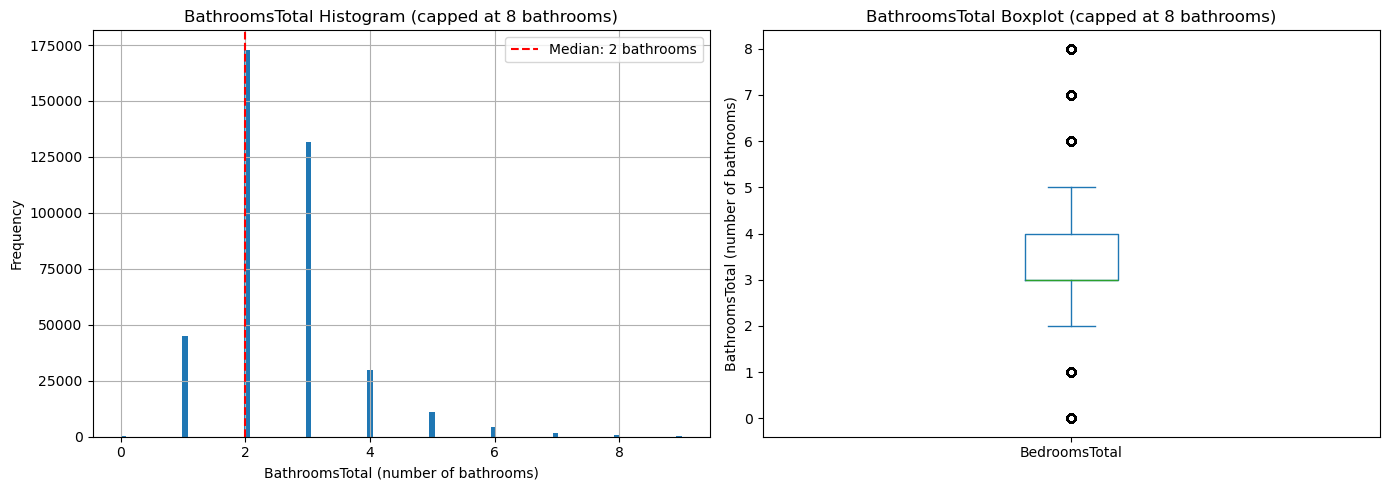

In [117]:
# Adjust upper cap based on what the percentile summary tells you
bth_total_cap = bth_total.quantile(0.999)
bth_total_trimmed = bth_total[bth_total <= bth_total_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bth_total_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(bth_total_trimmed.median(), color='red', linestyle='--', label=f'Median: {bth_total_trimmed.median():,.0f} bathrooms')
axes[0].set_title('BathroomsTotal Histogram (capped at 8 bathrooms)')
axes[0].set_xlabel('BathroomsTotal (number of bathrooms)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

bd_total_trimmed.plot.box(ax=axes[1])
axes[1].set_title('BathroomsTotal Boxplot (capped at 8 bathrooms)')
axes[1].set_ylabel('BathroomsTotal (number of bathrooms)')

plt.tight_layout()
plt.show()

#### DaysOnMarket

In [146]:
days_on_mkt = sold_ma['DaysOnMarket'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(days_on_mkt, p):,.0f} days on market")

print(f"\nMean:  {days_on_mkt.mean():,.0f} days on market")
print(f"Std:   {days_on_mkt.std():,.0f} days on market")
print(f"Count: {days_on_mkt.count():,} total entries")

1th percentile: 0 days on market
5th percentile: 1 days on market
10th percentile: 4 days on market
25th percentile: 8 days on market
50th percentile: 19 days on market
75th percentile: 48 days on market
90th percentile: 94 days on market
95th percentile: 131 days on market
99th percentile: 229 days on market
99.9th percentile: 431 days on market
100th percentile: 12,430 days on market

Mean:  37 days on market
Std:   54 days on market
Count: 397,603 total entries


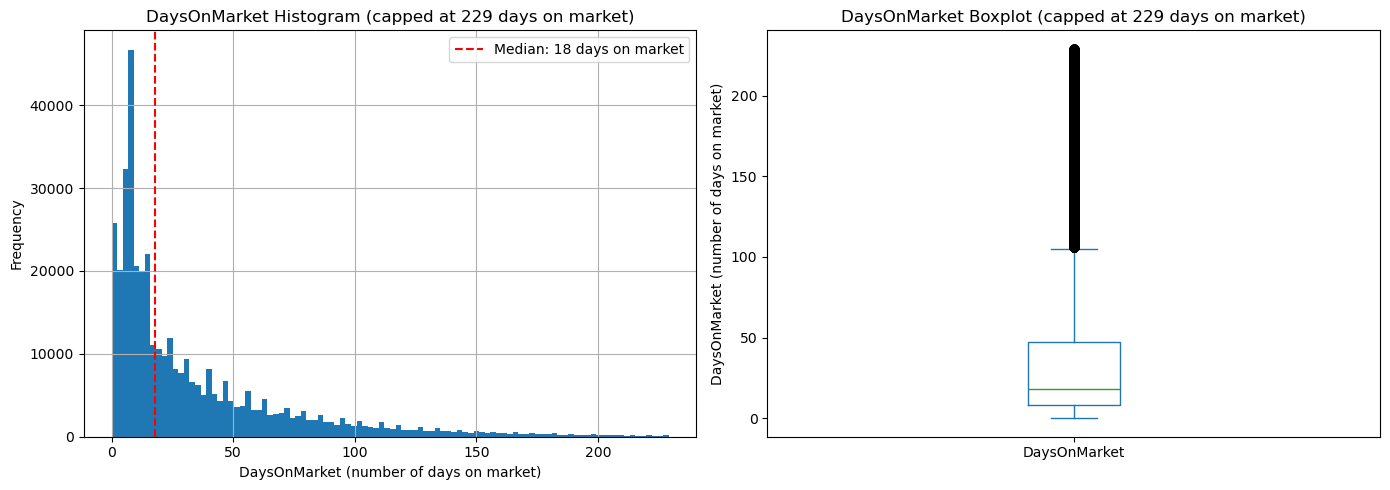

In [131]:
# Adjust upper cap based on what the percentile summary tells you
days_on_mkt_cap = days_on_mkt.quantile(0.99)
days_on_mkt_capped = days_on_mkt[days_on_mkt <= days_on_mkt_cap]
days_on_mkt_trimmed = days_on_mkt_capped[days_on_mkt_capped >= 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days_on_mkt_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(days_on_mkt_trimmed.median(), color='red', linestyle='--', label=f'Median: {days_on_mkt_trimmed.median():,.0f} days on market')
axes[0].set_title('DaysOnMarket Histogram (capped at 229 days on market)')
axes[0].set_xlabel('DaysOnMarket (number of days on market)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

days_on_mkt_trimmed.plot.box(ax=axes[1])
axes[1].set_title('DaysOnMarket Boxplot (capped at 229 days on market)')
axes[1].set_ylabel('DaysOnMarket (number of days on market)')

plt.tight_layout()
plt.show()

#### YearBuilt

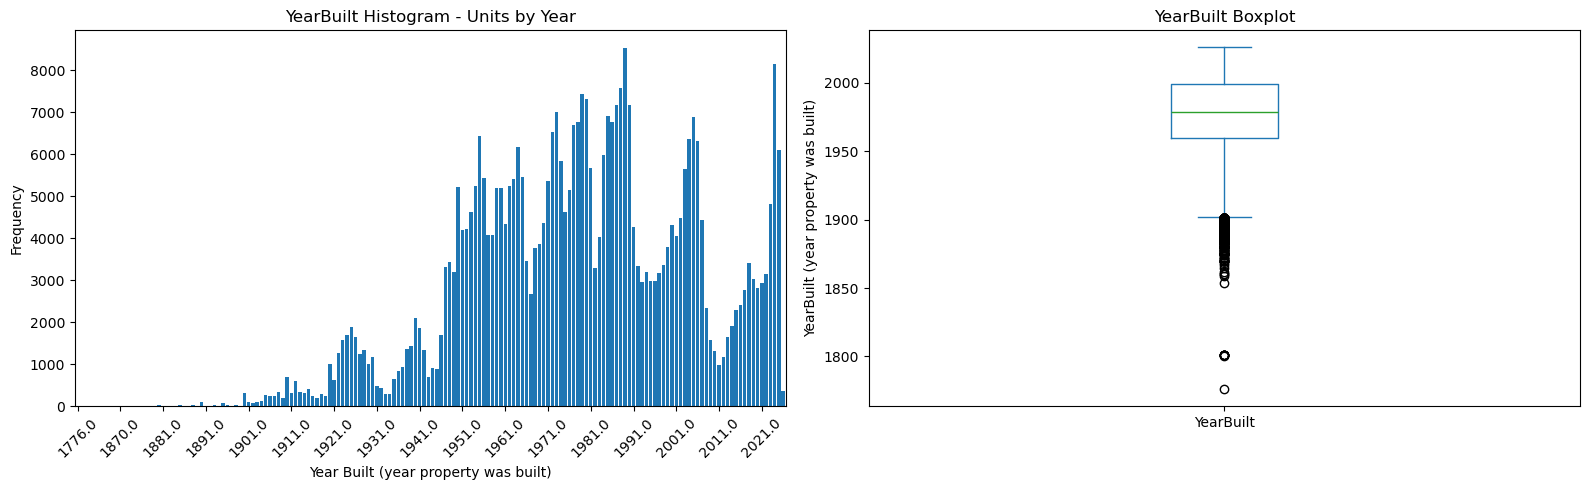

YearBuilt
1989.0    8526
2024.0    8153
1988.0    7574
1979.0    7428
1980.0    7321
1987.0    7165
1990.0    7165
1973.0    7001
1985.0    6912
2005.0    6892
1978.0    6780
1986.0    6779
1977.0    6694
1972.0    6529
1955.0    6433
2004.0    6363
2006.0    6307
1964.0    6163
2025.0    6092
1984.0    5975
Name: count, dtype: int64


In [163]:
yr_built = sold_ma['YearBuilt'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Value counts ranked by year (chronological, not by count)
yr_counts = yr_built.value_counts().sort_index()
yr_counts.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('YearBuilt Histogram - Units by Year')
axes[0].set_xlabel('Year Built (year property was built)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_locator(plt.MaxNLocator(20))  # prevent x-axis overcrowding
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Boxplot still works here
yr_built.plot.box(ax=axes[1])
axes[1].set_title('YearBuilt Boxplot')
axes[1].set_ylabel('YearBuilt (year property was built)')

plt.tight_layout()
plt.show()

# Top years by count
print(yr_built.value_counts().head(20))

In [154]:
property_age = 2026 - sold_ma['YearBuilt'].dropna()

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(property_age, p):,.0f} years old")

print(f"\nMean:  {property_age.mean():,.0f} years old")
print(f"Std:   {property_age.std():,.0f} years old")
print(f"Count: {property_age.count():,} total entries")

1th percentile: 1 years old
5th percentile: 4 years old
10th percentile: 10 years old
25th percentile: 27 years old
50th percentile: 47 years old
75th percentile: 66 years old
90th percentile: 79 years old
95th percentile: 96 years old
99th percentile: 114 years old
99.9th percentile: 131 years old
100th percentile: 250 years old

Mean:  47 years old
Std:   26 years old
Count: 397,247 total entries


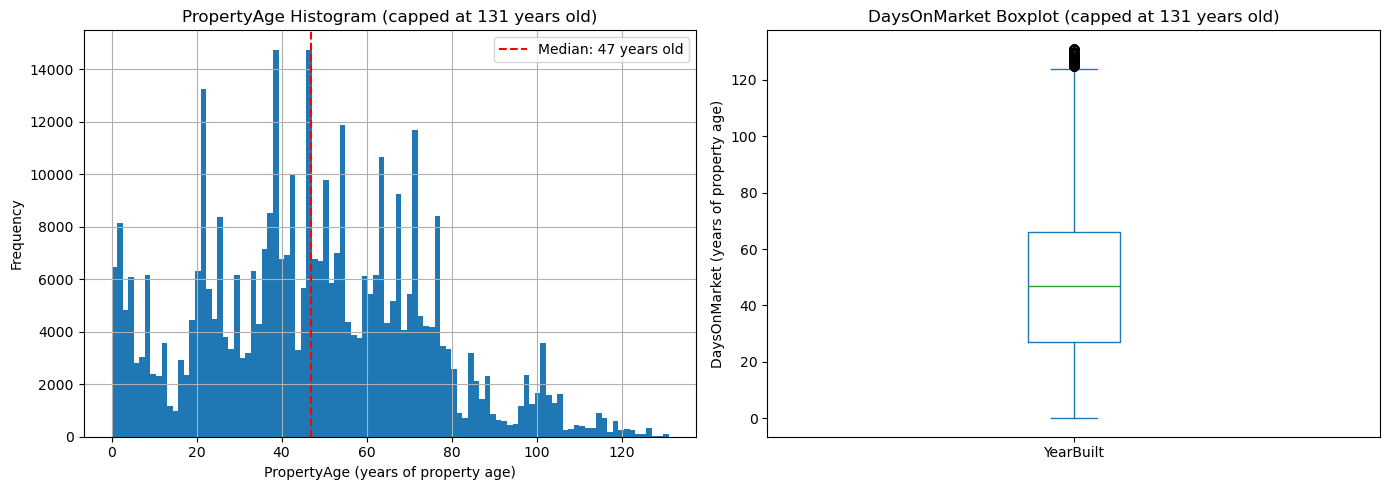

In [159]:
# Adjust upper cap based on what the percentile summary tells you
property_age_cap = property_age.quantile(0.999)
property_age_trimmed = property_age[property_age <= property_age_cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

property_age_trimmed.hist(bins=100, ax=axes[0])
axes[0].axvline(property_age_trimmed.median(), color='red', linestyle='--', label=f'Median: {property_age_trimmed.median():,.0f} years old')
axes[0].set_title('PropertyAge Histogram (capped at 131 years old)')
axes[0].set_xlabel('PropertyAge (years of property age)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

property_age_trimmed.plot.box(ax=axes[1])
axes[1].set_title('DaysOnMarket Boxplot (capped at 131 years old)')
axes[1].set_ylabel('DaysOnMarket (years of property age)')

plt.tight_layout()
plt.show()